<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
Random Forest - Diabetes
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Carga de librerias y de los datos procesados
</h2>

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Carga de datos guardados del proyecto anterior
</h2>

In [2]:
BASE_PATH = "../data/processed/diabetes_decision_tree/"

df = pd.read_csv(f"{BASE_PATH}diabetes_ready.csv")
X_train = pd.read_csv(f"{BASE_PATH}X_train.csv")
X_test = pd.read_csv(f"{BASE_PATH}X_test.csv")
y_train = pd.read_csv(f"{BASE_PATH}y_train.csv").squeeze("columns")
y_test = pd.read_csv(f"{BASE_PATH}y_test.csv").squeeze("columns")

print("Shape de df:", df.shape)
print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

display(X_train.head())

Shape de df: (768, 9)
Shape de X_train: (614, 8)
Shape de X_test: (154, 8)
Shape de y_train: (614,)
Shape de y_test: (154,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,90.0,62.0,12.0,43.0,27.2,0.580,24
1,5,126.0,78.0,27.0,22.0,29.6,0.439,40
2,2,105.0,58.0,40.0,94.0,34.9,0.225,25
3,1,146.0,56.0,29.0,125.0,29.7,0.564,29
4,0,95.0,64.0,39.0,105.0,44.6,0.366,22


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Entrenamiento del modelo base de Random Forest
</h2>

In [3]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

rf_metrics = pd.DataFrame({
    "dataset": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train, y_train_pred_rf),
        accuracy_score(y_test, y_test_pred_rf)
    ],
    "precision": [
        precision_score(y_train, y_train_pred_rf),
        precision_score(y_test, y_test_pred_rf)
    ],
    "recall": [
        recall_score(y_train, y_train_pred_rf),
        recall_score(y_test, y_test_pred_rf)
    ],
    "f1_score": [
        f1_score(y_train, y_train_pred_rf),
        f1_score(y_test, y_test_pred_rf)
    ]
})

rf_metrics

,dataset,accuracy,precision,recall,f1_score
0,train,1.000000,1.000000,1.000000,1.000000
1,test,0.779221,0.727273,0.592593,0.653061


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo de <span style="color:#D11A2A; font-weight:700;">Random Forest</span> logro un resultado perfecto en entrenamiento, con todas sus metricas en <span style="color:#D11A2A; font-weight:700;">1.00</span>. Aunque a primera vista parece excelente, en realidad esto suele ser una senal clara de que el modelo se ajusto demasiado a los datos de entrenamiento.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Cuando lo evaluo con datos nuevos, el rendimiento baja a un <span style="color:#D11A2A; font-weight:700;">77.9%</span> de accuracy. Esto me dice que el modelo no mantiene el mismo nivel fuera del entrenamiento y que existe <span style="color:#D11A2A; font-weight:700;">sobreajuste</span>.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Ademas, el valor de <span style="color:#D11A2A; font-weight:700;">recall = 0.5926</span> indica que el modelo esta dejando escapar varios casos reales de diabetes. Dicho de forma simple, cuando una persona realmente pertenece a la clase positiva, el modelo no siempre la detecta.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En resumen, este modelo base ofrece un resultado aceptable en prueba, pero todavia no esta bien equilibrado. El siguiente paso tiene sentido: ajustar hiperparametros para buscar un bosque mas estable, con mejor capacidad de generalizacion y una mejor deteccion de casos positivos.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Analisis de hiperparametros del Random Forest
</h2>

In [4]:
n_estimators_values = [10, 50, 100, 200, 300]
max_depth_values = [2, 4, 6, 8, 10, None]

rf_results = []

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        rf_results.append({
            "n_estimators": n_estimators,
            "max_depth": "None" if max_depth is None else max_depth,
            "accuracy_train": accuracy_score(y_train, y_train_pred),
            "accuracy_test": accuracy_score(y_test, y_test_pred)
        })

rf_results_df = pd.DataFrame(rf_results)
rf_results_df.sort_values(by="accuracy_test", ascending=False).reset_index(drop=True)

,n_estimators,max_depth,accuracy_train,accuracy_test
0,100,None,1.000000,0.779221
1,10,None,0.975570,0.772727
2,300,10,0.993485,0.759740
3,200,10,0.993485,0.753247
4,10,6,0.851792,0.753247
5,10,2,0.776873,0.753247
6,100,10,0.990228,0.753247
7,50,None,1.000000,0.746753
8,300,8,0.949511,0.746753
9,200,8,0.951140,0.746753


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La mejor combinacion en esta prueba fue <span style="color:#D11A2A; font-weight:700;">n_estimators = 100</span> y <span style="color:#D11A2A; font-weight:700;">max_depth = None</span>, con un <span style="color:#D11A2A; font-weight:700;">accuracy_test de 0.7792</span>. Esto significa que, de todas las opciones evaluadas, esta fue la que mejor respondio con datos nuevos.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aun asi, ese mismo modelo vuelve a sacar <span style="color:#D11A2A; font-weight:700;">1.00 en entrenamiento</span>, asi que el sobreajuste sigue presente. Dicho simple: sigue funcionando demasiado bien en train y bastante mas normal en test.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien se ve algo importante: aumentar mucho la cantidad de arboles <span style="color:#D11A2A; font-weight:700;">no garantiza mejorar</span>. Por ejemplo, pasar de 100 a 200 o 300 arboles no ayudo; de hecho, el rendimiento en prueba bajo en varias combinaciones.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Con la profundidad pasa algo parecido. Cuando limito demasiado el arbol, el modelo se vuelve mas simple y en algunos casos pierde capacidad para aprender patrones utiles. Pero cuando lo dejo muy libre, vuelve a ajustarse demasiado a los datos de entrenamiento.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En resumen, el mejor resultado de esta tabla no vino del modelo mas grande ni del mas restringido, sino de un punto intermedio en numero de arboles. El bosque mejora de forma aceptable, pero todavia no logra eliminar del todo el sobreajuste.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
📈 Grafico del impacto de los hiperparametros
</h2>

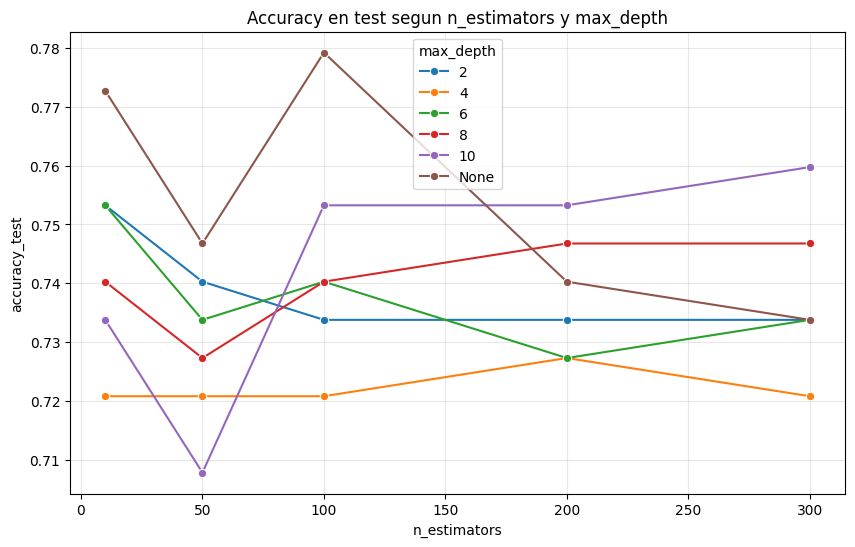

In [5]:
plot_df = rf_results_df.copy()
plot_df["max_depth"] = plot_df["max_depth"].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=plot_df,
    x="n_estimators",
    y="accuracy_test",
    hue="max_depth",
    marker="o"
)

plt.title("Accuracy en test segun n_estimators y max_depth")
plt.xlabel("n_estimators")
plt.ylabel("accuracy_test")
plt.grid(True, alpha=0.3)
plt.legend(title="max_depth")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En el grafico se observa que el <span style="color:#D11A2A; font-weight:700;">accuracy en test</span> no mejora de forma constante al aumentar la cantidad de arboles. Es decir, poner mas arboles no significa automaticamente obtener un mejor modelo.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La combinacion que mejor se comporto fue <span style="color:#D11A2A; font-weight:700;">100 arboles</span> con <span style="color:#D11A2A; font-weight:700;">max_depth = None</span>, ya que alcanzo el valor mas alto de accuracy en prueba. A partir de ahi, seguir aumentando los arboles no aporto una mejora real.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien se nota que las profundidades muy limitadas generan resultados mas modestos, mientras que las profundidades mas libres pueden rendir mejor, aunque siguen mostrando senales de <span style="color:#D11A2A; font-weight:700;">sobreajuste</span> cuando se comparan con entrenamiento.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En resumen, el grafico confirma que existe un punto donde el modelo da su mejor rendimiento y que, despues de ese punto, agregar complejidad ya no ayuda. Por eso, en este caso, conviene quedarse con una configuracion equilibrada en lugar de usar el bosque mas grande posible.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Seleccion del mejor modelo y guardado final
</h2>

In [6]:
best_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

best_rf_model.fit(X_train, y_train)

final_model_path = "../models/random_forest_diabetes.pkl"
joblib.dump(best_rf_model, final_model_path)

print("Modelo guardado en:", final_model_path)

Modelo guardado en: ../models/random_forest_diabetes.pkl


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo final elegido fue el de <span style="color:#D11A2A; font-weight:700;">100 arboles</span> con <span style="color:#D11A2A; font-weight:700;">max_depth = None</span>, porque fue la combinacion que logro el mejor resultado con datos de prueba.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aunque todavia muestra sobreajuste, fue la opcion mas fuerte dentro de todas las que se compararon. Por eso tiene sentido guardarlo como modelo final del proyecto.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Guardar el modelo en un archivo permite reutilizarlo despues de forma rapida, por ejemplo para hacer nuevas predicciones o integrarlo en otro flujo de trabajo sin tener que repetir todo el entrenamiento.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Conclusion final
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este proyecto construi un modelo de <span style="color:#D11A2A; font-weight:700;">Random Forest</span> para predecir diabetes a partir de los datos procesados del trabajo anterior. Primero entrene un modelo base y luego compare distintas combinaciones de <span style="color:#D11A2A; font-weight:700;">n_estimators</span> y <span style="color:#D11A2A; font-weight:700;">max_depth</span> para ver como cambiaba el rendimiento.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El mejor resultado en prueba se obtuvo con <span style="color:#D11A2A; font-weight:700;">100 arboles</span> y <span style="color:#D11A2A; font-weight:700;">max_depth = None</span>, alcanzando un <span style="color:#D11A2A; font-weight:700;">accuracy de 0.7792</span>. Esto me dice que, dentro de las opciones evaluadas, esa fue la configuracion que mejor respondio con datos nuevos.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aun asi, el modelo siguio mostrando <span style="color:#D11A2A; font-weight:700;">sobreajuste</span>, ya que en entrenamiento alcanzo metricas perfectas y en prueba bajo de forma clara. Ademas, el <span style="color:#D11A2A; font-weight:700;">recall</span> del modelo base mostro que todavia se escapan varios casos positivos, asi que aunque el resultado es aceptable, todavia hay margen de mejora.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien pude comprobar que aumentar mucho la cantidad de arboles no mejora automaticamente el modelo. En este caso, usar mas arboles o cambiar demasiado la profundidad no dio mejores resultados, asi que la mejor opcion fue una configuracion equilibrada y no simplemente la mas grande.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Finalmente, guarde el modelo seleccionado en la carpeta correspondiente para poder reutilizarlo mas adelante. Con esto, el proyecto queda completo: cargue los datos, entrene y compare el bosque aleatorio, analice su comportamiento y almacene el modelo final.
  </p>
</div>